In [ ]:
import numpy as np
from scipy import stats as st
from scipy import special as sp
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.ticker import PercentFormatter, FuncFormatter
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerPatch
import seaborn as sns
import pandas as pd
import os
import json
import decimal
from itertools import product
from scipy import ndimage

In [ ]:
root_dir = '../simulations'
params_path = os.path.join(root_dir, 'map_params.json')
params = json.load(open(params_path))

# Read map parameters.
eps = params['eps']
alpha = params['alpha']
ps = {1: params['p1'], 2: params['p2']} # misclassification rates
Ns = {1: params['N1dot']*params['px_per_km2'], 2: params['N2dot']*params['px_per_km2']} # mapped areas (pixels)

In [ ]:
red = '#ff0000'
cyan = '#00eeee'
grey = "#808080"
dark = "#07051b"
black = '#000000'
sns.set_style('darkgrid')


### Setup

In [ ]:
# Edit this value to inspect a different vertical slice of the original heatmap.
n = 400

# Same horizontal scale as the original heatmap's d range.
max_d = .5

# If d_prop is None, the notebook chooses the smallest distance threshold
# whose exceedance probability is at most target_prob. This corresponds to
# the red 5% contour in the original plot for this n.
d_prop = None
d_prop = 0.
target_prob = .05
# target_prob = .0

# Number of decimals used when aggregating equal endpoint values for plotting.
# This only affects plotting compactness, not the exact probability summaries below.
round_digits = 12


### Calculate the joint distribution of the CI endpoints for this $n$

In [ ]:
def allocated_sample_sizes(n):
    """Use the same allocation rule as the original heatmap notebook."""
    if n < 2:
        raise ValueError('n must be at least 2 so that both strata receive at least one sample.')

    n2 = int(np.round((n-2) / (1 + Ns[1]/Ns[2]*(ps[1]*(1-ps[1])/ps[2]/(1-ps[2]))**.5))) + 1
    n1 = n - n2

    if min(n1, n2) < 1:
        raise ValueError(f'Invalid allocation for n={n}: n1={n1}, n2={n2}.')

    return n1, n2


def weighted_pmf(values, weights, ndigits=12):
    """Aggregate a weighted discrete distribution, rounded only for display."""
    vals = np.round(np.ravel(values).astype(float), ndigits)
    w = np.ravel(weights).astype(float)

    order = np.argsort(vals)
    vals = vals[order]
    w = w[order]

    is_new = np.r_[True, vals[1:] != vals[:-1]]
    starts = np.flatnonzero(is_new)
    vals_unique = vals[starts]
    w_unique = np.add.reduceat(w, starts)

    return vals_unique, w_unique


def weighted_cdf(values, weights, ndigits=12):
    """Return x and F(x)=Pr(value <= x) for a weighted discrete distribution."""
    x, p = weighted_pmf(values, weights, ndigits=ndigits)
    return x, np.cumsum(p)


N = sum(Ns.values())
N_dot1 = Ns[1]*(1-ps[1]) + Ns[2]*ps[2]
z = st.norm.ppf(1 - alpha/2)

n1, n2 = allocated_sample_sizes(n)

x1 = np.arange(n1 + 1)[:, None]
x2 = np.arange(n2 + 1)[None, :]

p_x1 = st.binom.pmf(np.arange(n1 + 1), n1, ps[1])
p_x2 = st.binom.pmf(np.arange(n2 + 1), n2, ps[2])
Pr = np.outer(p_x1, p_x2)

N_dot1_hat = Ns[1]*(1 - x1/n1) + Ns[2]*x2/n2
std = (Ns[1]**2*x1*(n1-x1)/n1**3 + Ns[2]**2*x2*(n2-x2)/n2**3)**.5

L = N_dot1_hat - z*std
U = N_dot1_hat + z*std

Z_L = (L - N_dot1)/N_dot1
Z_U = (U - N_dot1)/N_dot1

D = np.maximum.reduce([np.zeros_like(L), N_dot1 - U, L - N_dot1])
D_prop = D / N_dot1

assert np.isclose(Pr.sum(), 1, atol=1e-10), Pr.sum()

### Coverage and distance summaries

In [ ]:
# Coverage decomposition.
Pr_below_truth = Pr[U < N_dot1].sum()       # CI entirely below the truth.
Pr_above_truth = Pr[L > N_dot1].sum()       # CI entirely above the truth.
coverage = 1 - Pr_below_truth - Pr_above_truth

# Same quantities read from the endpoint CDFs at zero.
F_U_0_minus = Pr_below_truth                # Pr(Z_U < 0)
F_L_0 = Pr[L <= N_dot1].sum()               # Pr(Z_L <= 0)
assert np.isclose(coverage, F_L_0 - F_U_0_minus, atol=1e-10)

# Endpoint CDFs.
x_L, y_L = weighted_cdf(Z_L, Pr, ndigits=round_digits)
x_U, y_U = weighted_cdf(Z_U, Pr, ndigits=round_digits)


def discrete_quantile_from_cdf(x, y, q):
    """Smallest x such that F(x) >= q."""
    idx = np.flatnonzero(y >= q)
    if len(idx) == 0:
        return float(x[-1]), float(y[-1])
    i = idx[0]
    return float(x[i]), float(y[i])


# One-sided 5% endpoint tolerances.
# Left side: U too far below N_dot1, read from the 5% quantile of U.
# Right side: L too far above N_dot1, read from the 95% quantile of L.
if d_prop is None:
    U_5pct_rel, F_U_5pct = discrete_quantile_from_cdf(x_U, y_U, target_prob)
    L_95pct_rel, F_L_95pct = discrete_quantile_from_cdf(x_L, y_L, 1 - target_prob)

    d_U_low_prop = max(0.0, -U_5pct_rel)
    d_L_high_prop = max(0.0, L_95pct_rel)
else:
    # Manual symmetric override, kept for quick sensitivity checks.
    d_U_low_prop = float(d_prop)
    d_L_high_prop = float(d_prop)

    U_5pct_rel = -d_U_low_prop
    L_95pct_rel = d_L_high_prop
    F_U_5pct = target_prob
    F_L_95pct = 1 - target_prob

left_boundary = -d_U_low_prop
right_boundary = d_L_high_prop

show_left_band = d_U_low_prop > 0
show_right_band = d_L_high_prop > 0

# Show the quantile guides only when the corresponding one-sided miss probability is at least 5%
# and the quantile falls on the expected side of the truth.
show_U_quantile = (Pr_below_truth >= target_prob) and (U_5pct_rel < 0)
show_L_quantile = (Pr_above_truth >= target_prob) and (L_95pct_rel > 0)

# Distance-exceedance decomposition for the selected asymmetric tolerances.
Pr_too_low_by_d = Pr[Z_U < left_boundary].sum() if show_left_band else 0.0
Pr_too_high_by_d = Pr[Z_L > right_boundary].sum() if show_right_band else 0.0
Pr_distance_gt_d = Pr_too_low_by_d + Pr_too_high_by_d

summary = pd.DataFrame({
    'quantity': [
        'n', 'n1', 'n2', 'N_dot1',
        'Pr(CI below truth)', 'Pr(CI above truth)', 'coverage',
        'd_U_low_prop', 'd_L_high_prop',
        'Pr(U < N_dot1*(1-d_U_low_prop))',
        'Pr(L > N_dot1*(1+d_L_high_prop))',
        'Pr(one-sided distance exceeds tolerance)',
    ],
    'value': [
        n, n1, n2, N_dot1,
        Pr_below_truth, Pr_above_truth, coverage,
        d_U_low_prop, d_L_high_prop,
        Pr_too_low_by_d, Pr_too_high_by_d,
        Pr_distance_gt_d,
    ]
})
summary


,quantity,value
0,n,4.000000e+02
1,n1,1.400000e+01
2,n2,3.860000e+02
3,N_dot1,3.486997e+07
4,Pr(CI below truth),1.601963e-01
5,Pr(CI above truth),1.949413e-03
6,coverage,8.378543e-01
7,d_U_low_prop,0.000000e+00
8,d_L_high_prop,0.000000e+00
9,Pr(U < N_dot1*(1-d_U_low_prop)),0.000000e+00


### Plot

In [ ]:
def make_legend_arrow(legend, orig_handle, xdescent, ydescent, width, height, fontsize):
    y = ydescent + 0.5 * height
    return FancyArrowPatch(
        (xdescent - 0.05 * width, y),
        (xdescent + 1.15 * width, y),
        arrowstyle='<->',
        mutation_scale=0.9 * fontsize,
        lw=orig_handle.get_linewidth(),
        color=black,
        shrinkA=0,
        shrinkB=0,
    )

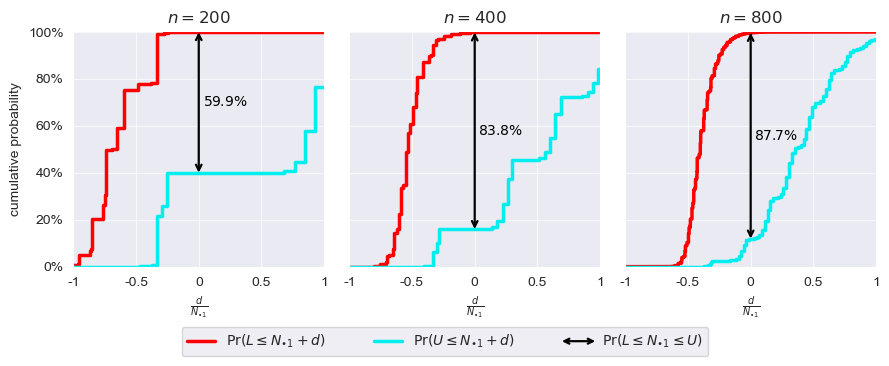

In [ ]:
plot_ns = [200, 400, 800]

def endpoint_cdf_quantities(n):
    n1, n2 = allocated_sample_sizes(n)

    x1 = np.arange(n1 + 1)[:, None]
    x2 = np.arange(n2 + 1)[None, :]

    p_x1 = st.binom.pmf(np.arange(n1 + 1), n1, ps[1])
    p_x2 = st.binom.pmf(np.arange(n2 + 1), n2, ps[2])
    Pr = np.outer(p_x1, p_x2)

    N_dot1_hat = Ns[1]*(1 - x1/n1) + Ns[2]*x2/n2
    std = (Ns[1]**2*x1*(n1-x1)/n1**3 + Ns[2]**2*x2*(n2-x2)/n2**3)**.5

    L = N_dot1_hat - z*std
    U = N_dot1_hat + z*std

    Z_L = (L - N_dot1)/N_dot1
    Z_U = (U - N_dot1)/N_dot1

    assert np.isclose(Pr.sum(), 1, atol=1e-10), Pr.sum()

    # Coverage decomposition.
    Pr_below_truth = Pr[U < N_dot1].sum()       # CI entirely below the truth.
    Pr_above_truth = Pr[L > N_dot1].sum()       # CI entirely above the truth.
    coverage = 1 - Pr_below_truth - Pr_above_truth

    # Same quantities read from the endpoint CDFs at zero.
    F_U_0_minus = Pr_below_truth                # Pr(Z_U < 0)
    F_L_0 = Pr[L <= N_dot1].sum()               # Pr(Z_L <= 0)
    assert np.isclose(coverage, F_L_0 - F_U_0_minus, atol=1e-10)

    # Endpoint CDFs.
    x_L, y_L = weighted_cdf(Z_L, Pr, ndigits=round_digits)
    x_U, y_U = weighted_cdf(Z_U, Pr, ndigits=round_digits)

    # One-sided 5% endpoint tolerances.
    # Left side: U too far below N_dot1, read from the 5% quantile of U.
    # Right side: L too far above N_dot1, read from the 95% quantile of L.
    if d_prop is None:
        U_5pct_rel, F_U_5pct = discrete_quantile_from_cdf(x_U, y_U, target_prob)
        L_95pct_rel, F_L_95pct = discrete_quantile_from_cdf(x_L, y_L, 1 - target_prob)

        d_U_low_prop = max(0.0, -U_5pct_rel)
        d_L_high_prop = max(0.0, L_95pct_rel)
    else:
        # Manual symmetric override, kept for quick sensitivity checks.
        d_U_low_prop = float(d_prop)
        d_L_high_prop = float(d_prop)

        U_5pct_rel = -d_U_low_prop
        L_95pct_rel = d_L_high_prop
        F_U_5pct = target_prob
        F_L_95pct = 1 - target_prob

    left_boundary = -d_U_low_prop
    right_boundary = d_L_high_prop

    show_left_band = d_U_low_prop > 0
    show_right_band = d_L_high_prop > 0

    # Show the quantile guides only when the corresponding one-sided miss probability is at least 5%
    # and the quantile falls on the expected side of the truth.
    show_U_quantile = (Pr_below_truth >= target_prob) and (U_5pct_rel < 0)
    show_L_quantile = (Pr_above_truth >= target_prob) and (L_95pct_rel > 0)

    return dict(
        n=n, n1=n1, n2=n2,
        x_L=x_L, y_L=y_L, x_U=x_U, y_U=y_U,
        coverage=coverage, F_U_0_minus=F_U_0_minus, F_L_0=F_L_0,
        U_5pct_rel=U_5pct_rel, L_95pct_rel=L_95pct_rel,
        d_U_low_prop=d_U_low_prop, d_L_high_prop=d_L_high_prop,
        left_boundary=left_boundary, right_boundary=right_boundary,
        show_left_band=show_left_band, show_right_band=show_right_band,
        show_U_quantile=show_U_quantile, show_L_quantile=show_L_quantile,
    )


quantities = [endpoint_cdf_quantities(n) for n in plot_ns]
show_any_U_quantile = any(q['show_U_quantile'] for q in quantities)
show_any_L_quantile = any(q['show_L_quantile'] for q in quantities)

fig, axes = plt.subplots(1, len(plot_ns), figsize=(9, 4), sharey=True)
axes = np.atleast_1d(axes)
# fig.patch.set_facecolor(grey)   # outside plotting area
# ax.set_facecolor('#A0A0A0')          # plotting area

legend_handles = {}

for ax, q in zip(axes, quantities):
    # Keep the same compact horizontal scale unless the selected one-sided tolerance is wider.
    x_left = -max(max_d, 1.05*q['d_U_low_prop'])
    x_right = max(max_d, 1.05*q['d_L_high_prop'])
    x_left = -1
    x_right = 1
    xlim = (x_left, x_right)

    # Asymmetric tolerance bands.
    if q['show_left_band']:
        left_band = ax.axvspan(
            q['left_boundary'], 0,
            color=grey, alpha=.5, lw=0, zorder=0,
            label=r'tolerance for $U$ missing $N_{\bullet 1}$ from below'
        )
        legend_handles.setdefault('left_band', left_band)
    else:
        left_band = None

    if q['show_right_band']:
        right_band = ax.axvspan(
            0, q['right_boundary'],
            color=grey, alpha=.7, lw=0, zorder=0,
            label=r'tolerance for $L$ above $N_{\bullet 1}$'
        )
        legend_handles.setdefault('right_band', right_band)
    else:
        right_band = None


    # Endpoint CDFs.
    lower_line, = ax.step(q['x_L'], q['y_L'], where='post', color=red, lw=2.5,
                          label=r'$\Pr(L \leq N_{{\bullet 1}}+d)$')
    upper_line, = ax.step(q['x_U'], q['y_U'], where='post', color=cyan, lw=2.5,
                          label=r'$\Pr(U \leq N_{{\bullet 1}}+d)$')
    legend_handles.setdefault('lower_line', lower_line)
    legend_handles.setdefault('upper_line', upper_line)

    # One-sided 5% quantile projections.
    dash = (0, (4, 3))
    if q['show_U_quantile']:
        ax.plot([xlim[0], q['U_5pct_rel']], [target_prob, target_prob],
                color=black, lw=1.2, linestyle=dash, zorder=4)
        # ax.plot([q['U_5pct_rel'], q['U_5pct_rel']], [0, 1],
        #         color=black, lw=1.2, linestyle=dash, zorder=4)
        ax.scatter([q['U_5pct_rel']], [target_prob], color=black, s=20, zorder=6)
        # ax.text(q['U_5pct_rel'], -.035, r'$d_{U,95\%}$',
        #         color=black, ha='center', va='top',
        #         transform=ax.get_xaxis_transform())

    if q['show_L_quantile']:
        ax.plot([xlim[0], q['L_95pct_rel']], [1 - target_prob, 1 - target_prob],
                color=black, lw=1.2, linestyle=dash, zorder=4)
        # ax.plot([q['L_95pct_rel'], q['L_95pct_rel']], [0, 1],
        #         color=black, lw=1.2, linestyle=dash, zorder=4)
        ax.scatter([q['L_95pct_rel']], [1 - target_prob], color=black, s=20, zorder=6)
        # ax.text(q['L_95pct_rel'], -.035, r'$d_{L,95\%}$',
        #         color=black, ha='center', va='top',
        #         transform=ax.get_xaxis_transform())

    # Coverage gap: F_L(0) - F_U(0-).
    ax.annotate(
        '',
        xy=(0, q['F_L_0']), xytext=(0, q['F_U_0_minus']),
        arrowprops=dict(
            arrowstyle='<->', color=black, lw=1.6,
            linestyle='-', shrinkA=0, shrinkB=0, mutation_scale=10,
        ),
        zorder=5,
    )
    coverage_line = plt.Line2D(
        [0], [0], color=black, lw=1.6,
        label=r'$\Pr(L \leq N_{{\bullet 1}} \leq U)$'
    )
    coverage_handle = FancyArrowPatch(
        (0, 0), (1, 0),
        arrowstyle='<->',
        mutation_scale=10,
        lw=1.6,
        color=black,
        linestyle='-',
        label=r'$\Pr(L \leq N_{{\bullet 1}} \leq U)$'
    )
    legend_handles.setdefault('coverage_handle', coverage_handle)

    coverage_str = f'{q["coverage"]:.1%}'.replace('%', r'\%')
    ax.text(.015*(xlim[1] - xlim[0]),
            .5*(q['F_L_0'] + q['F_U_0_minus']),
            rf'${coverage_str}$',
            color=black, ha='left', va='center')

    # Put the truth label directly below the zero tick.
    def relative_error_formatter(x, pos):
        return f'{x:g}'
    ax.xaxis.set_major_formatter(FuncFormatter(relative_error_formatter))

    ax.set_xlim(xlim)
    y_eps = .003
    ax.set_ylim(-y_eps, 1 + y_eps)

    # Keep the y-axis in percent, but leave the x-axis in raw relative-error units.
    ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
    yticks = list(ax.get_yticks())
    if show_any_U_quantile:
        yticks.append(target_prob)
    if show_any_L_quantile:
        yticks.append(1 - target_prob)
    yticks = sorted(t for t in set(np.round(yticks, 10)) if -y_eps <= t <= 1 + y_eps)
    ax.set_yticks(yticks)

    ax.set_xlabel(r'$\frac{d}{N_{\bullet 1}}$')#, labelpad=18)
    ax.set_title(rf'$n={q["n"]}$')

    ax.grid(True, color='w', lw=.5)

axes[0].set_ylabel('cumulative probability')

handles = [
    legend_handles[key] for key in [
        'lower_line', 'upper_line', 'coverage_handle',
        'left_band', 'right_band',
    ] if key in legend_handles
]
# ax.legend(handles=handles, loc='lower right', frameon=True)
coverage_handle = FancyArrowPatch(
    (0, 0), (2, 0),
    arrowstyle='<->',
    mutation_scale=10,
    lw=1.6,
    color=black,
    label=r'$\Pr(L \leq N_{{\bullet 1}} \leq U)$'
)

fig.legend(
    handles=handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.08),
    ncol=4,
    columnspacing=3.5,
    frameon=True,
    handler_map={FancyArrowPatch: HandlerPatch(patch_func=make_legend_arrow)}
)

fig.tight_layout(rect=[0, .15, 1, 1])

plt.savefig(f'S2_endpoint_CDF_n={"_".join(map(str, plot_ns))}.png', bbox_inches='tight', dpi=600)
plt.show()
